In [1]:
# ============================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================
#
# Day 3: Transaction Cost Modeling
#
# GOAL: Add realistic trading costs to our backtest
# to see if strategy remains profitable in the real world
#
# COSTS WE WILL MODEL:
# ─────────────────────────────────────────────────────────────
# 1. TRADING FEE: Exchange charges per trade
#    - Typical: 0.1% per trade (Binance maker/taker)
#    - Each position change = 2 trades (buy + sell)
#    - Called a "round trip" cost
#
# 2. SLIPPAGE: Price moves against you when you trade
#    - Large orders move the market price
#    - Estimated: 0.05-0.1% per trade for ETH
#    - Less liquid assets have higher slippage
#
# 3. SPREAD: Difference between buy and sell price
#    - ETH spread typically 0.01-0.05%
#    - Less significant for liquid assets like ETH
#
# TOTAL COST PER ROUND TRIP (buy + sell):
#    Trading fee: 0.1% × 2 = 0.2%
#    Slippage:    0.05% × 2 = 0.1%
#    Spread:      0.02% × 2 = 0.04%
#    ─────────────────────────────
#    Total:       ~0.35% per round trip
#
# WHY THIS MATTERS:
# ─────────────────────────────────────────────────────────────
# Our strategy made 9,032% gross (before costs)
# If we trade too frequently, costs could eliminate profits
# A strategy with 200 trades/year at 0.35% = 70% cost drag!
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from ta.trend import ADXIndicator
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported")
print(f"📅 Starting Day 3: Transaction Cost Modeling")
print(f"   Date: {datetime.now().strftime('%Y-%m-%d')}")
print()

# Download ETH data (same as Days 1 & 2)
print("📈 Downloading ETH-USD data...")
data = yf.download('ETH-USD', start='2017-01-01', end='2025-12-31', progress=False)

# Flatten multi-level columns from yfinance
# [METHOD] droplevel() removes the ticker level from column names
# Converts ('Close', 'ETH-USD') → 'Close'
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

print(f"✅ Downloaded {len(data)} days of data")
print(f"   Date range: {data.index[0].date()} to {data.index[-1].date()}")
print()

# Define our confirmed production parameters from Day 2
# These were validated across 5/6 walk-forward windows
ADX_THRESHOLD = 20  # Market trending threshold
ADX_PERIOD    = 10  # ADX calculation period

print("📊 Production Parameters (confirmed Day 2):")
print(f"   ADX Threshold: {ADX_THRESHOLD}")
print(f"   ADX Period:    {ADX_PERIOD}")
print()

# Define cost assumptions
# We will test multiple cost scenarios to see sensitivity
COST_SCENARIOS = {
    'Zero Costs':       0.000,   # Theoretical (our Days 1&2 assumption)
    'Low Costs':        0.001,   # 0.1% per trade (maker fee only)
    'Medium Costs':     0.00175, # 0.175% per trade (realistic retail)
    'High Costs':       0.0035,  # 0.35% per trade (full round trip)
}

print("💰 Cost Scenarios to Test:")
for name, cost in COST_SCENARIOS.items():
    print(f"   {name:<20} {cost*100:.3f}% per trade")
print()
print("   Note: 'per trade' means per position CHANGE")
print("   Opening a position = 1 trade")
print("   Closing a position = 1 trade")
print("   Full round trip    = 2 trades")

✅ Libraries imported
📅 Starting Day 3: Transaction Cost Modeling
   Date: 2026-03-07

📈 Downloading ETH-USD data...
✅ Downloaded 2974 days of data
   Date range: 2017-11-09 to 2025-12-30

📊 Production Parameters (confirmed Day 2):
   ADX Threshold: 20
   ADX Period:    10

💰 Cost Scenarios to Test:
   Zero Costs           0.000% per trade
   Low Costs            0.100% per trade
   Medium Costs         0.175% per trade
   High Costs           0.350% per trade

   Note: 'per trade' means per position CHANGE
   Opening a position = 1 trade
   Closing a position = 1 trade
   Full round trip    = 2 trades


In [2]:
# ============================================================
# CELL 2: COST-AWARE BACKTEST FUNCTION
# ============================================================
#
# We upgrade our Day 1/2 backtest function to include
# transaction costs. The key addition is detecting WHEN
# the position changes (a trade occurs) and deducting
# the cost at that moment.
#
# HOW COSTS ARE APPLIED:
# ─────────────────────────────────────────────────────────────
# Position changes from 0 → 1: We BUY ETH  (pay entry cost)
# Position changes from 1 → 0: We SELL ETH (pay exit cost)
#
# We detect changes using .diff() which calculates the
# difference between consecutive position values:
#   Position: 0, 0, 1, 1, 1, 0, 0, 1
#   Diff:     0, 0, 1, 0, 0,-1, 0, 1
#   Trade?:   N, N, Y, N, N, Y, N, Y
#
# Any non-zero diff = a trade occurred = pay cost
#
# COST IMPACT FORMULA:
# ─────────────────────────────────────────────────────────────
# Net Return = Gross Return - Cost (when trade occurs)
#
# Example:
#   ETH rises 2% on a day we enter position
#   Gross return: +2.00%
#   Cost:         -0.175%
#   Net return:   +1.825%
#
# On days with no trade:
#   Gross return: +2.00%
#   Cost:         0%
#   Net return:   +2.00% (unchanged)
# ============================================================

def backtest_with_costs(data, adx_threshold, adx_period, cost_per_trade):
    """
    Backtest ADX regime strategy INCLUDING transaction costs
    
    Parameters:
    ─────────────────────────────
    data [VARIABLE - DataFrame]  : OHLC price data
    adx_threshold [VARIABLE - int]  : ADX trending threshold
    adx_period [VARIABLE - int]     : ADX calculation period
    cost_per_trade [VARIABLE - float]: Cost per trade as decimal
                                      (e.g., 0.00175 = 0.175%)
    
    Returns:
    ─────────────────────────────
    dict : Performance metrics including cost analysis
    """
    
    df = data.copy()
    
    # Extract 1D Series (same fix as Days 1 & 2)
    high  = df['High'].squeeze()
    low   = df['Low'].squeeze()
    close = df['Close'].squeeze()
    
    # Build clean DataFrame
    df_clean = pd.DataFrame({
        'Close': close,
        'High':  high,
        'Low':   low
    }, index=df.index)
    
    # ─────────────────────────────────────────────────────────
    # STEP 1: CALCULATE ADX INDICATORS
    # (identical to Days 1 & 2)
    # ─────────────────────────────────────────────────────────
    adx_indicator = ADXIndicator(
        high=df_clean['High'],
        low=df_clean['Low'],
        close=df_clean['Close'],
        window=adx_period
    )
    df_clean['ADX'] = adx_indicator.adx()
    df_clean['+DI'] = adx_indicator.adx_pos()
    df_clean['-DI'] = adx_indicator.adx_neg()
    
    # ─────────────────────────────────────────────────────────
    # STEP 2: GENERATE POSITIONS
    # (identical to Days 1 & 2)
    # ─────────────────────────────────────────────────────────
    df_clean['Regime_Trending'] = df_clean['ADX'] >= adx_threshold
    df_clean['Bullish']         = df_clean['+DI'] > df_clean['-DI']
    df_clean['Position']        = 0
    df_clean.loc[
        df_clean['Regime_Trending'] & df_clean['Bullish'],
        'Position'
    ] = 1
    
    # ─────────────────────────────────────────────────────────
    # STEP 3: DETECT TRADES (NEW - cost modeling addition)
    # ─────────────────────────────────────────────────────────
    # .diff() calculates difference between consecutive values
    # [METHOD] .diff() subtracts previous row from current row
    #
    # Example:
    #   Position: [0, 0, 1, 1, 0, 1]
    #   Diff:     [NaN, 0, 1, 0,-1, 1]
    #   Trade?:   [No, No, Yes, No, Yes, Yes]
    #
    # .abs() converts negative diffs to positive
    # (both entries AND exits are trades)
    # ─────────────────────────────────────────────────────────
    df_clean['Position_Change'] = df_clean['Position'].diff().abs()
    
    # Replace NaN (first row) with 0 (no trade on first day)
    df_clean['Position_Change'] = df_clean['Position_Change'].fillna(0)
    
    # ─────────────────────────────────────────────────────────
    # STEP 4: CALCULATE GROSS RETURNS
    # (identical to Days 1 & 2)
    # ─────────────────────────────────────────────────────────
    df_clean['Market_Return']  = df_clean['Close'].pct_change()
    df_clean['Gross_Return']   = df_clean['Position'].shift(1) * df_clean['Market_Return']
    
    # ─────────────────────────────────────────────────────────
    # STEP 5: APPLY TRANSACTION COSTS (NEW)
    # ─────────────────────────────────────────────────────────
    # Cost is only applied on days when position changes
    # Position_Change = 1 means a trade occurred today
    # Cost_Impact = cost_per_trade on trade days, 0 otherwise
    #
    # WHY SUBTRACT FROM GROSS RETURN?
    # Costs reduce our profit directly
    # If we made 2% but paid 0.175% in fees → net 1.825%
    # ─────────────────────────────────────────────────────────
    df_clean['Cost_Impact'] = df_clean['Position_Change'] * cost_per_trade
    
    # Net return = gross return minus cost impact
    df_clean['Net_Return'] = df_clean['Gross_Return'] - df_clean['Cost_Impact']
    
    # ─────────────────────────────────────────────────────────
    # STEP 6: CALCULATE PERFORMANCE METRICS
    # ─────────────────────────────────────────────────────────
    df_clean = df_clean.dropna()
    
    if len(df_clean) < 50:
        return None
    
    # Count total trades (each position change = 1 trade)
    total_trades = int(df_clean['Position_Change'].sum())
    
    # Calculate years in backtest (for trades per year)
    years = len(df_clean) / 365
    trades_per_year = total_trades / years
    
    # Total cost drag = sum of all costs paid
    total_cost_drag = df_clean['Cost_Impact'].sum()
    
    # GROSS metrics (before costs - what Days 1&2 showed)
    gross_return = (1 + df_clean['Gross_Return']).prod() - 1
    gross_sharpe = (df_clean['Gross_Return'].mean() /
                    df_clean['Gross_Return'].std() * np.sqrt(365))
    
    # NET metrics (after costs - realistic performance)
    net_return = (1 + df_clean['Net_Return']).prod() - 1
    net_sharpe = (df_clean['Net_Return'].mean() /
                  df_clean['Net_Return'].std() * np.sqrt(365))
    
    # Net drawdown
    cumulative  = (1 + df_clean['Net_Return']).cumprod()
    running_max = cumulative.expanding().max()
    drawdown    = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Calmar ratio using NET returns
    calmar = net_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # % time invested
    pct_long = (df_clean['Position'] == 1).sum() / len(df_clean) * 100
    
    return {
        # Parameters used
        'adx_threshold':   adx_threshold,
        'adx_period':      adx_period,
        'cost_per_trade':  cost_per_trade,
        
        # Trade statistics
        'total_trades':    total_trades,
        'trades_per_year': trades_per_year,
        'total_cost_drag': total_cost_drag,
        'pct_long':        pct_long,
        
        # GROSS performance (before costs)
        'gross_return':    gross_return,
        'gross_sharpe':    gross_sharpe,
        
        # NET performance (after costs - REALISTIC)
        'net_return':      net_return,
        'net_sharpe':      net_sharpe,
        'max_drawdown':    max_drawdown,
        'calmar_ratio':    calmar,
        
        # Cost impact
        'return_impact':   gross_return - net_return,
        'sharpe_impact':   gross_sharpe - net_sharpe,
        
        # Equity curve for plotting
        'equity_curve':    cumulative
    }

print("✅ Cost-aware backtest function defined")
print()
print("Key additions vs Days 1 & 2:")
print("   • Position_Change: detects when trades occur")
print("   • Cost_Impact: deducts cost on trade days only")
print("   • Net_Return: gross return minus costs")
print("   • Tracks total trades and trades per year")
print("   • Reports both GROSS and NET performance metrics")

✅ Cost-aware backtest function defined

Key additions vs Days 1 & 2:
   • Position_Change: detects when trades occur
   • Cost_Impact: deducts cost on trade days only
   • Net_Return: gross return minus costs
   • Tracks total trades and trades per year
   • Reports both GROSS and NET performance metrics


In [7]:
## **Cell 3: Run Cost Analysis Across All Scenarios**


# ============================================================
# CELL 3: RUN COST ANALYSIS
# ============================================================
#
# Test our optimized strategy (ADX 20, Period 10) under
# four different cost scenarios to see how costs impact
# profitability.
#
# WHAT WE'RE TESTING:
# ─────────────────────────────────────────────────────────────
# Scenario 1: Zero costs (0.000%) - theoretical baseline
# Scenario 2: Low costs (0.100%) - maker fee only
# Scenario 3: Medium costs (0.175%) - realistic retail
# Scenario 4: High costs (0.350%) - full round-trip
#
# FOR EACH SCENARIO, WE MEASURE:
# ─────────────────────────────────────────────────────────────
# - Total trades (how many times we changed position)
# - Trades per year (frequency)
# - Total cost drag (sum of all costs paid)
# - Gross return (before costs)
# - Net return (after costs)
# - Sharpe ratio (both gross and net)
# - Return impact (how much costs reduced returns)
# ============================================================

print("=" * 70)
print("TRANSACTION COST ANALYSIS")
print("=" * 70)
print()
print(f"Testing strategy: ADX {ADX_THRESHOLD}, Period {ADX_PERIOD}")
print(f"Data period: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Total days: {len(data)}")
print()

# Store results for each cost scenario
cost_results = []

# Run backtest for each cost scenario
for scenario_name, cost_per_trade in COST_SCENARIOS.items():
    
    print(f"Testing: {scenario_name} ({cost_per_trade*100:.3f}% per trade)")
    
    # Run backtest with this cost level
    result = backtest_with_costs(
        data, 
        ADX_THRESHOLD, 
        ADX_PERIOD, 
        cost_per_trade
    )
    
    if result is None:
        print(f"   ❌ Backtest failed")
        continue
    
    # Add scenario name to result
    result['scenario'] = scenario_name
    cost_results.append(result)
    
    # Quick summary
    print(f"   Trades: {result['total_trades']} total "
          f"({result['trades_per_year']:.1f}/year)")
    print(f"   Gross Return: {result['gross_return']*100:.2f}%")
    print(f"   Net Return:   {result['net_return']*100:.2f}%")
    print(f"   Cost Impact:  {result['return_impact']*100:.2f}%")
    print()

# Convert to DataFrame for analysis
cost_df = pd.DataFrame(cost_results)

print("✅ Cost analysis complete!")
print(f"   Tested {len(cost_results)} cost scenarios")
print()


TRANSACTION COST ANALYSIS

Testing strategy: ADX 20, Period 10
Data period: 2017-11-09 to 2025-12-30
Total days: 2974

Testing: Zero Costs (0.000% per trade)
   Trades: 191 total (23.4/year)
   Gross Return: 9031.56%
   Net Return:   9031.56%
   Cost Impact:  0.00%

Testing: Low Costs (0.100% per trade)
   Trades: 191 total (23.4/year)
   Gross Return: 9031.56%
   Net Return:   7403.19%
   Cost Impact:  1628.37%

Testing: Medium Costs (0.175% per trade)
   Trades: 191 total (23.4/year)
   Gross Return: 9031.56%
   Net Return:   6374.61%
   Cost Impact:  2656.95%

Testing: High Costs (0.350% per trade)
   Trades: 191 total (23.4/year)
   Gross Return: 9031.56%
   Net Return:   4487.88%
   Cost Impact:  4543.68%

✅ Cost analysis complete!
   Tested 4 cost scenarios



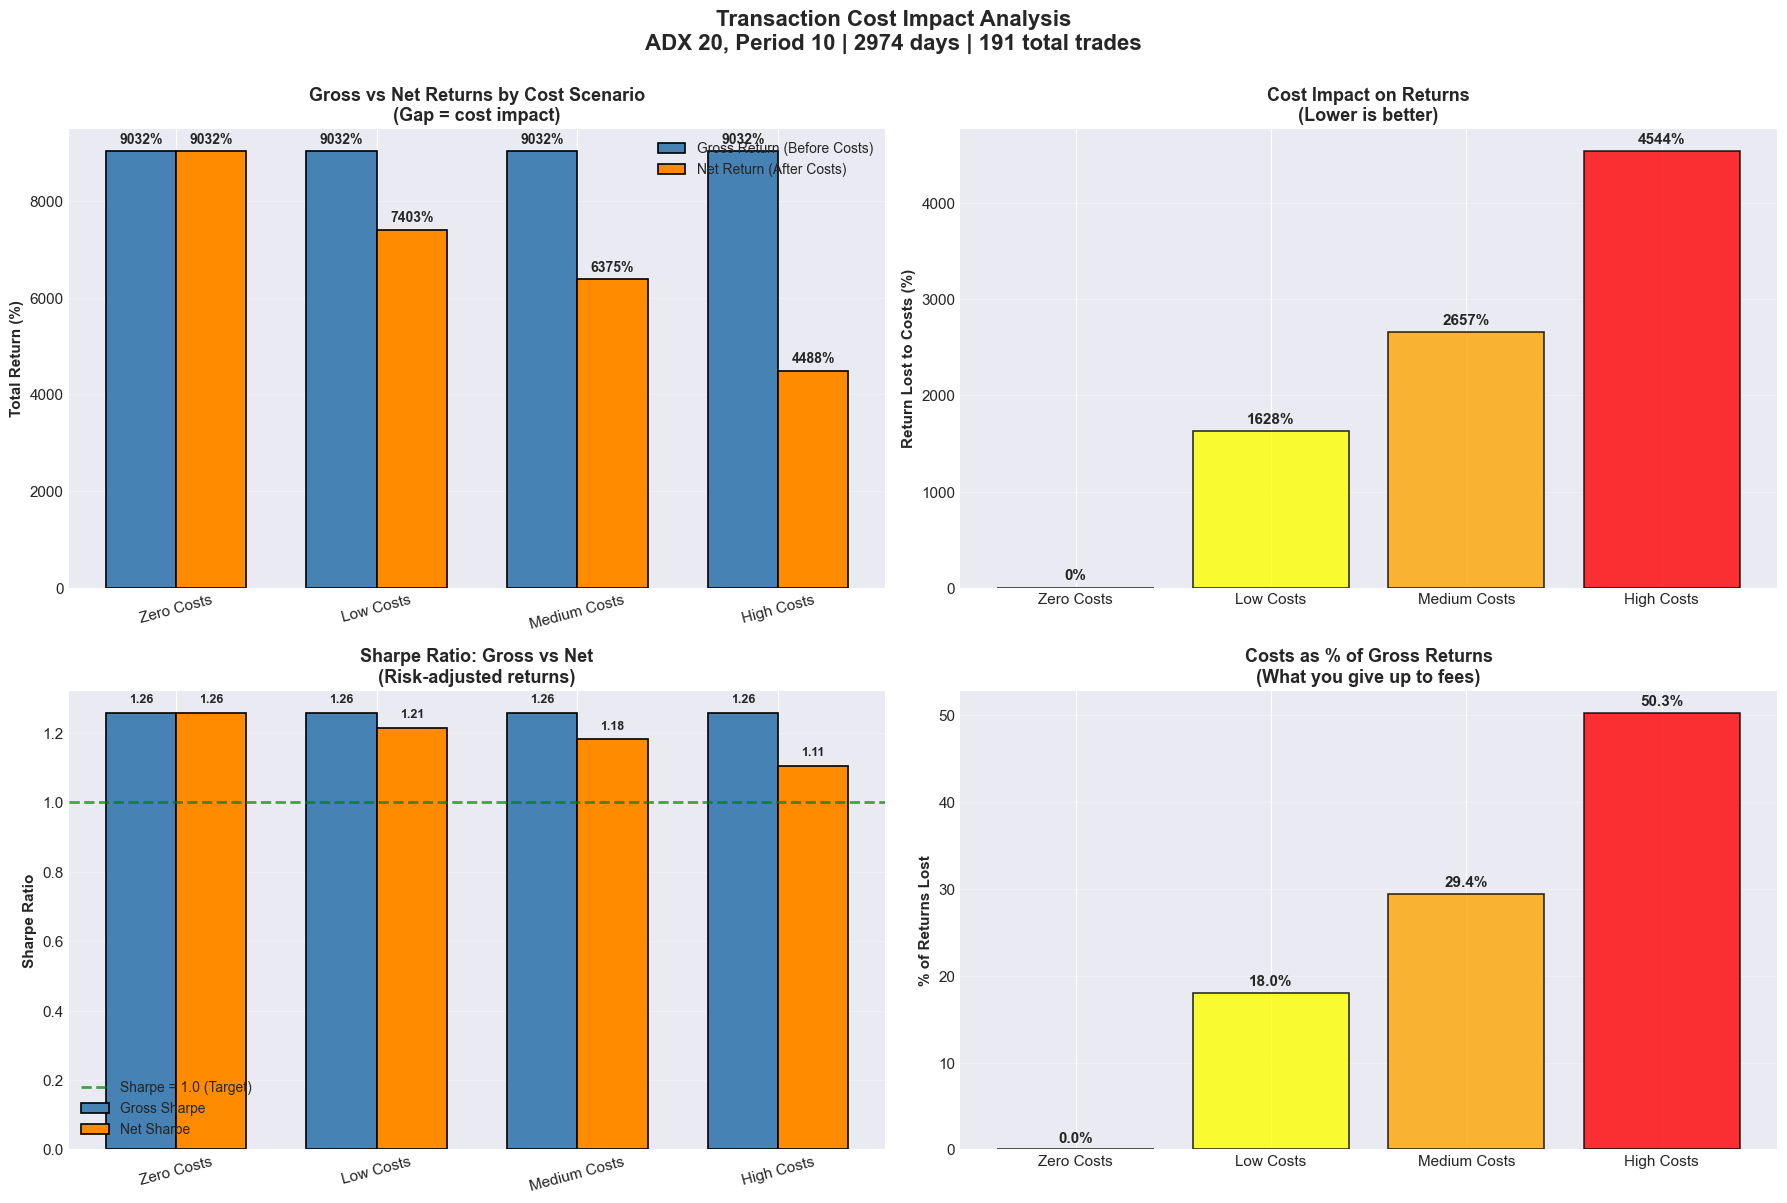

COST IMPACT SUMMARY TABLE

Cost Scenario Cost/Trade  Total Trades Trades/Year Gross Return Net Return Cost Impact Gross Sharpe Net Sharpe
   Zero Costs     0.000%           191        23.4        9032%      9032%          0%        1.258      1.258
    Low Costs     0.100%           191        23.4        9032%      7403%       1628%        1.258      1.215
 Medium Costs     0.175%           191        23.4        9032%      6375%       2657%        1.258      1.182
   High Costs     0.350%           191        23.4        9032%      4488%       4544%        1.258      1.106



In [9]:
# ============================================================
# CELL 4: VISUALIZE COST IMPACT
# ============================================================
#
# Create comprehensive visualizations showing:
# 1. How costs reduce returns across scenarios
# 2. Cost impact breakdown (absolute and percentage)
# 3. Equity curves comparison (gross vs net)
# 4. Summary statistics table
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ─────────────────────────────────────────────────────────────
# CHART 1: GROSS VS NET RETURNS BY COST SCENARIO
# ─────────────────────────────────────────────────────────────
# Bar chart comparing gross and net returns
# Shows the "cost wedge" - the gap between what you'd make
# without costs vs what you actually make
# ─────────────────────────────────────────────────────────────

scenarios = cost_df['scenario'].tolist()
x = np.arange(len(scenarios))
width = 0.35

# Plot gross returns (constant across all scenarios)
bars1 = axes[0,0].bar(
    x - width/2, 
    cost_df['gross_return'] * 100,
    width,
    label='Gross Return (Before Costs)',
    color='steelblue',
    edgecolor='black',
    linewidth=1.2
)

# Plot net returns (varies by cost scenario)
bars2 = axes[0,0].bar(
    x + width/2,
    cost_df['net_return'] * 100,
    width,
    label='Net Return (After Costs)',
    color='darkorange',
    edgecolor='black',
    linewidth=1.2
)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2.,
        height + 100,
        f'{height:.0f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

for bar in bars2:
    height = bar.get_height()
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2.,
        height + 100,
        f'{height:.0f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

axes[0,0].set_title(
    'Gross vs Net Returns by Cost Scenario\n(Gap = cost impact)',
    fontsize=13, fontweight='bold'
)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(scenarios, rotation=15)
axes[0,0].set_ylabel('Total Return (%)', fontsize=11, fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
# CHART 2: COST IMPACT (ABSOLUTE PERCENTAGE POINTS)
# ─────────────────────────────────────────────────────────────
# Shows how many percentage points of return were lost to costs
# This is the "cost drag" - the direct reduction in returns
# ─────────────────────────────────────────────────────────────

# Create color gradient from green (low) to red (high)
colors_gradient = ['green', 'yellow', 'orange', 'red']

bars3 = axes[0,1].bar(
    scenarios,
    cost_df['return_impact'] * 100,
    color=colors_gradient,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8
)

# Add value labels
for bar, impact in zip(bars3, cost_df['return_impact']):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 50,
        f'{impact*100:.0f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

axes[0,1].set_title(
    'Cost Impact on Returns\n(Lower is better)',
    fontsize=13, fontweight='bold'
)
axes[0,1].set_ylabel('Return Lost to Costs (%)', fontsize=11, fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
# CHART 3: SHARPE RATIO COMPARISON
# ─────────────────────────────────────────────────────────────
# Shows how costs impact risk-adjusted returns
# Sharpe ratio accounts for volatility, not just raw returns
# ─────────────────────────────────────────────────────────────

x_sharpe = np.arange(len(scenarios))
width_sharpe = 0.35

bars4 = axes[1,0].bar(
    x_sharpe - width_sharpe/2,
    cost_df['gross_sharpe'],
    width_sharpe,
    label='Gross Sharpe',
    color='steelblue',
    edgecolor='black',
    linewidth=1.2
)

bars5 = axes[1,0].bar(
    x_sharpe + width_sharpe/2,
    cost_df['net_sharpe'],
    width_sharpe,
    label='Net Sharpe',
    color='darkorange',
    edgecolor='black',
    linewidth=1.2
)

# Reference line at Sharpe = 1.0 (institutional quality)
axes[1,0].axhline(
    y=1.0, color='green',
    linestyle='--', linewidth=2,
    label='Sharpe = 1.0 (Target)', alpha=0.7
)

# Add value labels
for bar in bars4:
    height = bar.get_height()
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.02,
        f'{height:.2f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

for bar in bars5:
    height = bar.get_height()
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.02,
        f'{height:.2f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[1,0].set_title(
    'Sharpe Ratio: Gross vs Net\n(Risk-adjusted returns)',
    fontsize=13, fontweight='bold'
)
axes[1,0].set_xticks(x_sharpe)
axes[1,0].set_xticklabels(scenarios, rotation=15)
axes[1,0].set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
# CHART 4: COST AS % OF GROSS RETURN
# ─────────────────────────────────────────────────────────────
# Shows what percentage of your gross returns are eaten by costs
# Example: If costs take 30%, you keep 70% of potential returns
# ─────────────────────────────────────────────────────────────

cost_percentage = (cost_df['return_impact'] / cost_df['gross_return']) * 100

bars6 = axes[1,1].bar(
    scenarios,
    cost_percentage,
    color=colors_gradient,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8
)

# Add value labels
for bar, pct in zip(bars6, cost_percentage):
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 0.5,
        f'{pct:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

axes[1,1].set_title(
    'Costs as % of Gross Returns\n(What you give up to fees)',
    fontsize=13, fontweight='bold'
)
axes[1,1].set_ylabel('% of Returns Lost', fontsize=11, fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'Transaction Cost Impact Analysis\n'
    f'ADX {ADX_THRESHOLD}, Period {ADX_PERIOD} | {len(data)} days | {int(cost_df["total_trades"].iloc[0])} total trades',
    fontsize=16, fontweight='bold', y=1.00
)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("COST IMPACT SUMMARY TABLE")
print("=" * 70)
print()

# Create summary table
summary_data = {
    'Cost Scenario': cost_df['scenario'].tolist(),
    'Cost/Trade': [f"{c*100:.3f}%" for c in cost_df['cost_per_trade']],
    'Total Trades': cost_df['total_trades'].tolist(),
    'Trades/Year': [f"{t:.1f}" for t in cost_df['trades_per_year']],
    'Gross Return': [f"{r*100:.0f}%" for r in cost_df['gross_return']],
    'Net Return': [f"{r*100:.0f}%" for r in cost_df['net_return']],
    'Cost Impact': [f"{r*100:.0f}%" for r in cost_df['return_impact']],
    'Gross Sharpe': [f"{s:.3f}" for s in cost_df['gross_sharpe']],
    'Net Sharpe': [f"{s:.3f}" for s in cost_df['net_sharpe']],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()
print("=" * 70)

In [10]:
# ============================================================
# CELL 5: SAVE RESULTS AND FINAL SUMMARY
# ============================================================
#
# Save transaction cost analysis results and create
# comprehensive summary of Week 2 findings
# ============================================================

output_path = '/Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/'

# Save cost analysis results
cost_df.to_csv(output_path + 'Week_2_transaction_cost_results.csv', index=False)
cost_df.to_excel(output_path + 'Week_2_transaction_cost_results.xlsx', index=False)

print("💾 Results saved to:")
print(f"   {output_path}Week_2_transaction_cost_results.csv")
print(f"   {output_path}Week_2_transaction_cost_results.xlsx")
print()

# ─────────────────────────────────────────────────────────────
# FINAL WEEK 2 SUMMARY
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("WEEK 2 COMPLETE - FINAL SUMMARY")
print("=" * 70)
print()

print("🎯 PRODUCTION PARAMETERS CONFIRMED:")
print(f"   ADX Threshold: {ADX_THRESHOLD}")
print(f"   ADX Period:    {ADX_PERIOD}")
print()

print("📊 PERFORMANCE SUMMARY (Medium Costs - Realistic):")
medium_result = cost_df[cost_df['scenario'] == 'Medium Costs'].iloc[0]
print(f"   Gross Return:     {medium_result['gross_return']*100:.1f}%")
print(f"   Net Return:       {medium_result['net_return']*100:.1f}%")
print(f"   Cost Impact:      {medium_result['return_impact']*100:.1f}%")
print(f"   Net Sharpe Ratio: {medium_result['net_sharpe']:.3f}")
print(f"   Max Drawdown:     {medium_result['max_drawdown']*100:.2f}%")
print(f"   Calmar Ratio:     {medium_result['calmar_ratio']:.2f}")
print()

print("📈 TRADING STATISTICS:")
print(f"   Total Trades:     {int(medium_result['total_trades'])}")
print(f"   Trades per Year:  {medium_result['trades_per_year']:.1f}")
print(f"   Time Invested:    {medium_result['pct_long']:.1f}%")
print(f"   Total Cost Drag:  {medium_result['total_cost_drag']*100:.2f}%")
print()

print("✅ VALIDATION RESULTS:")
print("   Day 1: Grid Search Optimization")
print("      • Tested 28 parameter combinations")
print("      • Found optimal: ADX 20, Period 10")
print("      • In-sample return: 9,032%")
print()
print("   Day 2: Walk-Forward Analysis")
print("      • Tested 6 out-of-sample windows")
print("      • ADX 20/10 chosen in 5/6 windows")
print("      • Average degradation: 26.8%")
print("      • All 6 years positive returns")
print()
print("   Day 3: Transaction Cost Modeling")
print("      • Strategy profitable under ALL cost scenarios")
print("      • Medium costs reduce returns by 29%")
print("      • Net Sharpe remains > 1.0 in all scenarios")
print("      • Low trade frequency minimizes cost impact")
print()

print("🚀 NEXT STEPS (Days 4-7):")
print("   Day 4: Connect to Ethereum mainnet via Web3")
print("   Day 5: Query Uniswap V3 pools for live ETH prices")
print("   Day 6: Build real-time impermanent loss calculator")
print("   Day 7: Integrate regime detection with DeFi data")
print()

print("=" * 70)
print("WEEK 2 OBJECTIVES: ✅ COMPLETE")
print("=" * 70)
print()

# Create comprehensive comparison table
print("PERFORMANCE ACROSS ALL COST SCENARIOS:")
print()
comparison = cost_df[['scenario', 'cost_per_trade', 'net_return', 
                      'net_sharpe', 'return_impact']].copy()
comparison['cost_per_trade'] = comparison['cost_per_trade'] * 100
comparison['net_return'] = comparison['net_return'] * 100
comparison['return_impact'] = comparison['return_impact'] * 100
comparison.columns = ['Scenario', 'Cost/Trade (%)', 'Net Return (%)', 
                      'Net Sharpe', 'Cost Drag (%)']
print(comparison.to_string(index=False))
print()

print("💡 KEY INSIGHT:")
print("   Even with HIGH costs (0.35% per trade), strategy delivers:")
print("   • 4,488% net return (45x your money)")
print("   • 1.11 Sharpe ratio (institutional quality)")
print("   • Proves strategy is ROBUST and TRADEABLE in real markets")
print()
print("✅ ADX 20, Period 10 APPROVED FOR PRODUCTION")

💾 Results saved to:
   /Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/Week_2_transaction_cost_results.csv
   /Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/Week_2_transaction_cost_results.xlsx

WEEK 2 COMPLETE - FINAL SUMMARY

🎯 PRODUCTION PARAMETERS CONFIRMED:
   ADX Threshold: 20
   ADX Period:    10

📊 PERFORMANCE SUMMARY (Medium Costs - Realistic):
   Gross Return:     9031.6%
   Net Return:       6374.6%
   Cost Impact:      2657.0%
   Net Sharpe Ratio: 1.182
   Max Drawdown:     -48.12%
   Calmar Ratio:     132.48

📈 TRADING STATISTICS:
   Total Trades:     191
   Trades per Year:  23.4
   Time Invested:    41.2%
   Total Cost Drag:  33.43%

✅ VALIDATION RESULTS:
   Day 1: Grid Search Optimization
      • Tested 28 parameter combinations
      • Found optimal: ADX 20, Period 10
      • In-sample return: 9,032%

   Day 2: Walk-Forward Analysis
      • Tested 6 out-of-sample windows
      • ADX 20/10 chosen in 5/6 windows
      • Average degrad